# Axe 3 — RFormer on Colab T4

Runs `experiments/chap5/5_4_1_rformer.py` on Colab's GPU runtime
from PyCharm's Jupyter integration.

**Prereq**: connect this notebook's Jupyter server to Google Colab in
PyCharm (Settings → Languages & Frameworks → Jupyter → Add Colab), then
choose the T4 runtime.

**Filesystem note**: cells execute on Colab's VM, not your laptop.
The repo is cloned from GitHub in the first cell so all local paths
(`data/processed/`, `results/chap5/`,
`results/reference/chap5/`) resolve against the clone.

## 1. Environment check

Verify the GPU is attached and install the two deps not preinstalled
on Colab (`iisignature`; `torch` and the rest are already there).

In [1]:
import torch
print('torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

!pip install -q iisignature

torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.7 MB/s eta 0:00:0000:010:01
  Preparing metadata (setup.py) ... done


## 2. Fetch the repo

Clones on first run, pulls latest on subsequent runs. All later cells
assume the working directory is the repo root.

In [2]:
import os
from google.colab import userdata

GH_USER = 'cnammastermlballa-dotcom'
GH_REPO = 'path-signature-benchmark'

# Try Colab's secrets store first. NOTE: userdata does NOT work from
# PyCharm-Colab — it only works in the Colab web UI. In PyCharm, use
# the getpass fallback below.
token = None
try:
    token = userdata.get('GH_TOKEN')
    print("Loaded GH_TOKEN from Colab secrets.")
except userdata.SecretNotFoundError:
    print("SecretNotFoundError: no secret named 'GH_TOKEN' exists.")
except userdata.NotebookAccessError:
    print("NotebookAccessError: secret exists but not granted to this notebook.")
except Exception as e:
    print(f"Cannot fetch Colab secret ({type(e).__name__}) — "
          "expected when running from PyCharm-Colab.")

# Interactive fallback: paste the PAT once, keep it in memory only.
if not token:
    import getpass
    typed = getpass.getpass(
        "Paste GH_TOKEN (hidden input), or press Enter to try public clone: "
    ).strip()
    if typed:
        token = typed

if token:
    REPO_URL = f'https://{token}@github.com/{GH_USER}/{GH_REPO}.git'
    print("Using token-authenticated clone URL.")
else:
    REPO_URL = f'https://github.com/{GH_USER}/{GH_REPO}.git'
    print("No token — falling back to public URL.")

if not os.path.exists(GH_REPO):
    !git clone {REPO_URL}
%cd {GH_REPO}
!git pull --ff-only

Cannot fetch Colab secret (TimeoutException) — expected when running from PyCharm-Colab.
Using token-authenticated clone URL.
Cloning into 'path-signature-benchmark'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 125 (delta 24), reused 122 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (125/125), 12.81 MiB | 30.21 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/path-signature-benchmark
Already up to date.


## 3. Run the Axe 3 pipeline

The script reads `optimal_N_{ds}.txt` (Axe 1 output) from `results/chap5/`.
A fresh clone has no `results/chap5/`, so the reference copies from
`results/reference/chap5/` are copied there first. It then prepares
multi-view signatures for CharTraj + NATOPS, trains RFormer, evaluates on
the held-out test set, and saves `results/chap5/5_4_1_rformer.{csv,png}`.

Expected wall time on T4: ~15-30 min (CharTraj dominates).

In [3]:
!mkdir -p results/chap5
!cp results/reference/chap5/optimal_N_*.txt results/chap5/
!python experiments/chap5/5_4_1_rformer.py

INFO — Running Axe 3 (RFormer) experiment...
INFO — Device: cuda
INFO — === CharTraj ===
INFO —   config=lin+time (hard-coded), N*=5 (from Axe 1)
INFO —   n_train=1422, n_test=1436, n_classes=20, T_target=122, n_windows=8 (overlap=50%)
INFO —   mvsig: train=(1422, 8, 1364), test=(1436, 8, 1364) (prep=5.3s)
/content/path-signature-benchmark/experiments/chap5/5_4_1_rformer.py:292: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
INFO —   RFormer: sig_dim=1364, n_windows=8, n_params=574868
INFO —     epoch   1: test_acc=0.897, lr=3.00e-04
INFO —     epoch  10: test_acc=0.975, lr=2.93e-04
INFO —     epoch  20: test_acc=0.975, lr=2.71e-04
INFO —     epoch  30: test_acc=0.976, lr=2.38e-04
INFO —     epoch  40: test_acc=0.976, lr=1.96e-04
INFO —     epoch  50: test_acc=0.976, lr=1.50e-04
INFO —     epoch  60: test_acc=0.976, lr=1.04e-04
INFO —     epoc

## 4. Inspect the results

,dataset,config,N,n_windows,sig_dim,test_accuracy,test_f1_macro,n_params,prep_time_s,train_time_s
0,CharTraj,lin+time,5,8,1364,0.976323,0.974097,574868,5.314110,15.421052
1,NATOPS,lin+time,3,8,16275,0.905556,0.905042,2481670,2.232254,1.904762


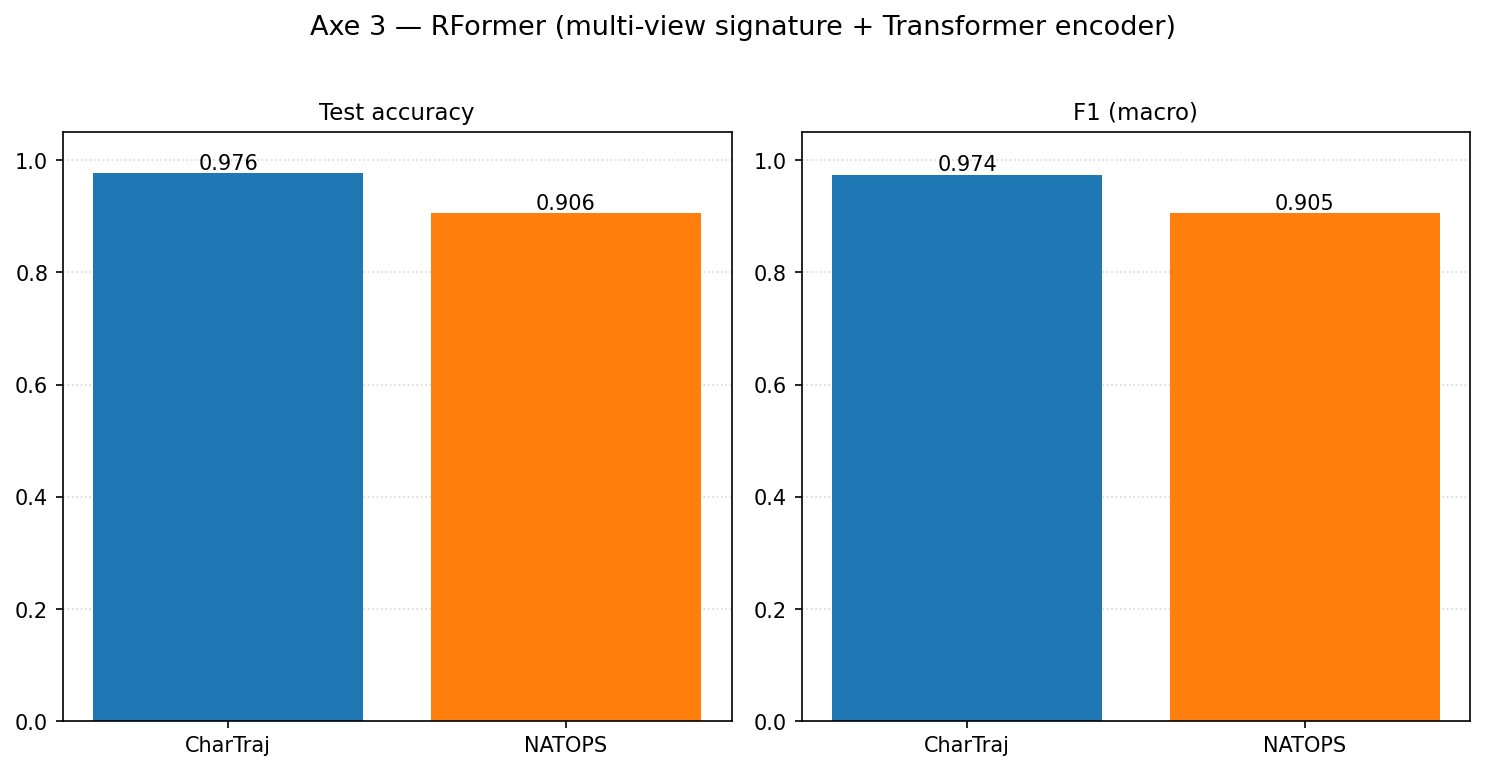

In [5]:
import pandas as pd
from IPython.display import Image, display

df = pd.read_csv('results/chap5/5_4_1_rformer.csv')
display(df)
display(Image('results/chap5/5_4_1_rformer.png'))

## 5. Commit results back to GitHub (optional)

`results/chap5/` is git-ignored: the new RFormer outputs are copied into
`results/reference/chap5/` (the committed reference results) and pushed.

Set your git identity and use a Personal Access Token so the push
authenticates non-interactively. **Do not paste the token into a cell
you commit** — set it as a Colab secret.

In Colab: `Tools → Manage secrets` and add `GH_TOKEN` (a fine-grained
PAT with `contents: write` on this repo).

In [6]:
from google.colab import userdata
import subprocess

GH_USER = 'cnammastermlballa-dotcom'
GH_REPO = 'path-signature-benchmark'

# Same token-fetching pattern as cell 2. userdata.get() fails from
# PyCharm-Colab, so we fall back to getpass.
token = None
try:
    token = userdata.get('GH_TOKEN')
    print("Loaded GH_TOKEN from Colab secrets.")
except Exception as e:
    print(f"Cannot fetch Colab secret ({type(e).__name__}) — "
          "expected when running from PyCharm-Colab.")

if not token:
    import getpass
    typed = getpass.getpass(
        "Paste GH_TOKEN with `contents: write` scope (hidden input): "
    ).strip()
    if typed:
        token = typed
    else:
        raise RuntimeError("No token provided — cannot push results.")

!git config user.name  'Thierry Balla (Colab)'
!git config user.email 'cnammastermlballa@gmail.com'
subprocess.run(
    ['git', 'remote', 'set-url', 'origin',
     f'https://{token}@github.com/{GH_USER}/{GH_REPO}.git'],
    check=True,
)

!cp results/chap5/5_4_1_rformer.csv results/chap5/5_4_1_rformer.png results/reference/chap5/
!git add results/reference/chap5/5_4_1_rformer.csv results/reference/chap5/5_4_1_rformer.png
!git commit -m 'Axe 3 results (Colab T4 run)' && git push

Cannot fetch Colab secret (TimeoutException) — expected when running from PyCharm-Colab.
[master b317489] Axe 3 results (Colab T4 run)
 2 files changed, 2 insertions(+), 2 deletions(-)
 rewrite results/chap5/5_4_1_rformer.png (93%)
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 31.80 KiB | 15.90 MiB/s, done.
Total 6 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/cnammastermlballa-dotcom/path-signature-benchmark.git
   7521752..b317489  master -> master
